decisionTree

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

df = pd.read_csv("titanic.csv")
print(f"Veri boyutu: {df.shape}")
df.info()

Veri boyutu: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [2]:
# Cabin: var/yok bilgisine cevir (0/1)
df["HasCabin"] = df["Cabin"].notnull().astype(int)

# Age: eksik degerleri medyan ile doldur
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: sadece 2 eksik deger var, en sik gorulen deger (mode) ile doldur
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Kullanmayacagimiz sutunlari atalim
df_model = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

print(df_model.isnull().sum())
print(df_model.head())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  HasCabin
0         0       3    male  22.0      1      0   7.2500        S         0
1         1       1  female  38.0      1      0  71.2833        C         1
2         1       3  female  26.0      0      0   7.9250        S         0
3         1       1  female  35.0      1      0  53.1000        S         1
4         0       3    male  35.0      0      0   8.0500        S         0


In [3]:
# Sex: male=0, female=1 gibi basitce cevirebiliriz (sadece 2 kategori oldugu icin)
df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

# Embarked: 3 kategori var (S, C, Q), one-hot encoding kullanalim
df_model = pd.get_dummies(df_model, columns=["Embarked"], drop_first=True)

print(df_model.head())
print(df_model.dtypes)

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  HasCabin  Embarked_Q  \
0         0       3    0  22.0      1      0   7.2500         0       False   
1         1       1    1  38.0      1      0  71.2833         1       False   
2         1       3    1  26.0      0      0   7.9250         0       False   
3         1       1    1  35.0      1      0  53.1000         1       False   
4         0       3    0  35.0      0      0   8.0500         0       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
HasCabin        int64
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [4]:
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Egitim seti: {X_train.shape}, Test seti: {X_test.shape}")
print(f"Egitimde hayatta kalma orani: {y_train.mean():.3f}")
print(f"Testte hayatta kalma orani: {y_test.mean():.3f}")

Egitim seti: (712, 9), Test seti: (179, 9)
Egitimde hayatta kalma orani: 0.383
Testte hayatta kalma orani: 0.385


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 4, 5, 6, 8, None],
        "min_samples_leaf": [1, 2, 5, 10],
        "min_samples_split": [2, 5, 10]
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
dt = dt_grid.best_estimator_

print("En iyi parametreler:", dt_grid.best_params_)
print(f"En iyi CV skoru: {dt_grid.best_score_:.4f}")

En iyi parametreler: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
En iyi CV skoru: 0.8202


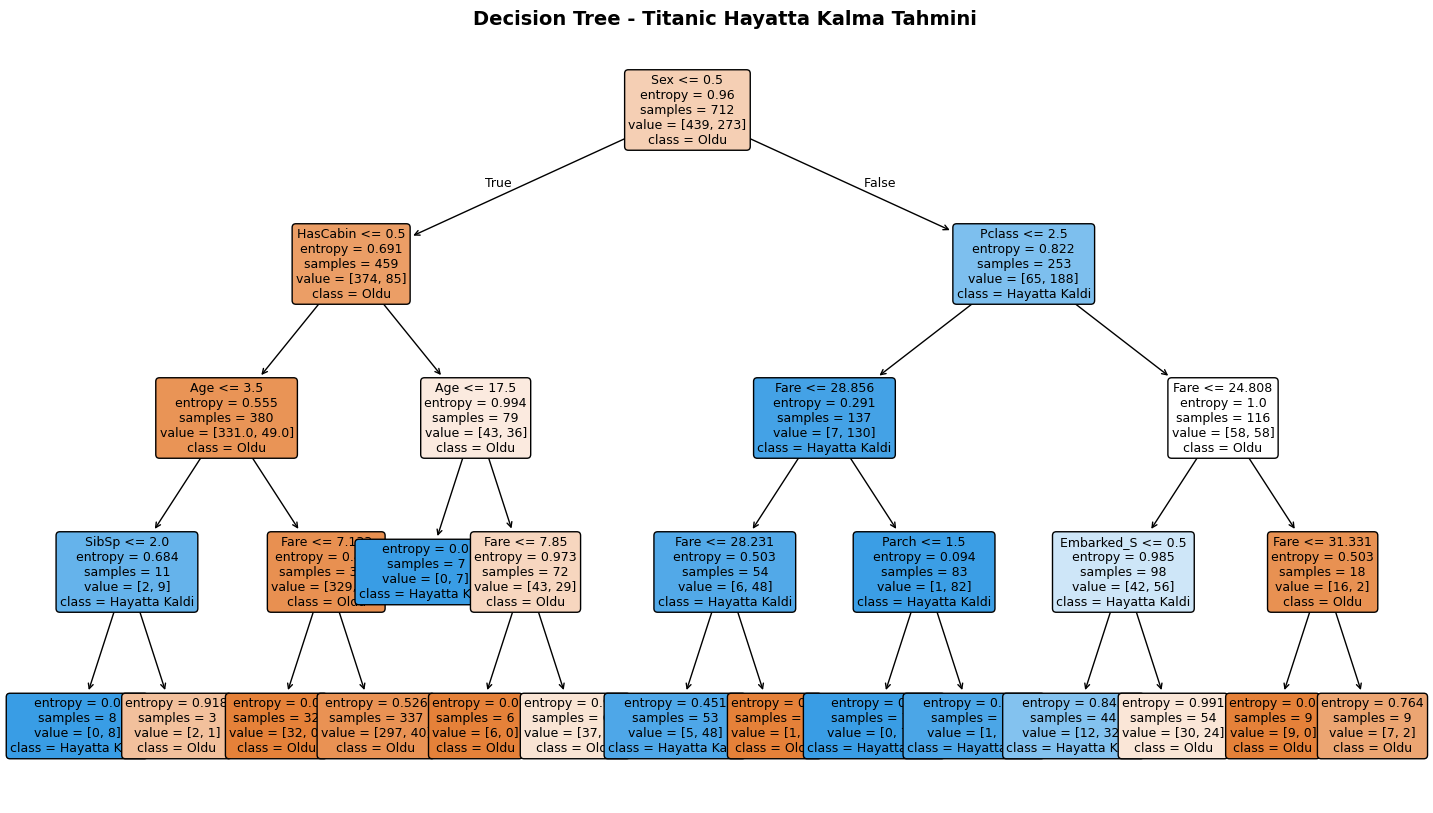

In [6]:
plt.figure(figsize=(18, 10))
plot_tree(dt, feature_names=X.columns, class_names=["Oldu", "Hayatta Kaldi"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree - Titanic Hayatta Kalma Tahmini", fontsize=14, fontweight="bold")
plt.show()

In [7]:
y_pred_dt = dt.predict(X_test)
print(f"Test dogrulugu: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Test dogrulugu: 0.7989
              precision    recall  f1-score   support

           0       0.78      0.95      0.85       110
           1       0.87      0.57      0.68        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179



In [ ]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 2, 5],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2"]
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

print("En iyi parametreler:", rf_grid.best_params_)
print(f"En iyi CV skoru: {rf_grid.best_score_:.4f}")

randomForest

In [8]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 2, 5],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2"]
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

print("En iyi parametreler:", rf_grid.best_params_)
print(f"En iyi CV skoru: {rf_grid.best_score_:.4f}")

En iyi parametreler: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
En iyi CV skoru: 0.8342


In [9]:
for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"========== {name} ==========")
    print(f"Test dogrulugu: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Ortalama 5 katli CV dogrulugu: {np.mean(cv_scores):.4f}")
    print(classification_report(y_test, y_pred))
    print()

========== Decision Tree ==========
Test dogrulugu: 0.7989
Ortalama 5 katli CV dogrulugu: 0.8202
              precision    recall  f1-score   support

           0       0.78      0.95      0.85       110
           1       0.87      0.57      0.68        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179


========== Random Forest ==========
Test dogrulugu: 0.7933
Ortalama 5 katli CV dogrulugu: 0.8342
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       110
           1       0.80      0.62      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179




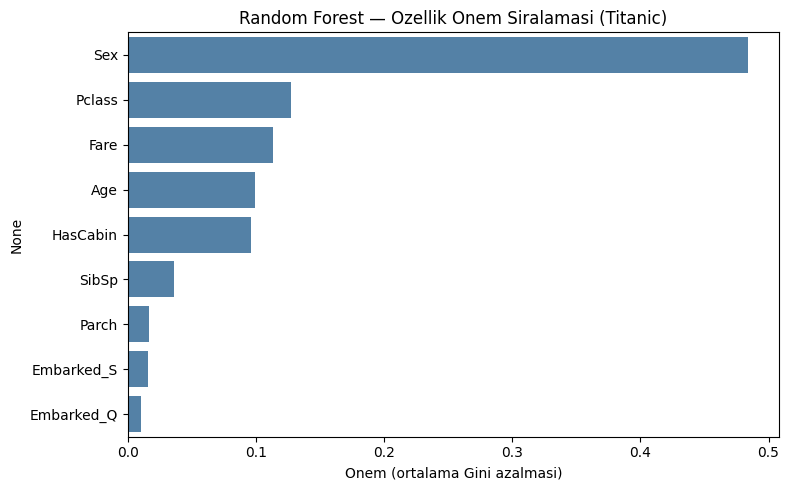

Sex           0.484135
Pclass        0.127319
Fare          0.113385
Age           0.099695
HasCabin      0.096590
SibSp         0.036297
Parch         0.016986
Embarked_S    0.015499
Embarked_Q    0.010095
dtype: float64


In [10]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Onem (ortalama Gini azalmasi)")
plt.title("Random Forest — Ozellik Onem Siralamasi (Titanic)")
plt.tight_layout()
plt.show()

print(imp)